# AIS Track Completeness

This notebook evaluates AIS vessel-track completeness using
the MarineCadastre AIS sample.

Metrics:
- Percentage of gaps
- Maximum gap duration

In [3]:
import pandas as pd
import numpy as np

In [4]:
ais_path = "../../data/ais/ais-2025-01-08.csv.zst"

df = pd.read_csv(
    ais_path,
    compression="zstd"
)

print("Rows:", len(df))
print("Columns:", df.columns.tolist())

Rows: 5929631
Columns: ['mmsi', 'base_date_time', 'longitude', 'latitude', 'sog', 'cog', 'heading', 'vessel_name', 'imo', 'call_sign', 'vessel_type', 'status', 'length', 'width', 'draft', 'cargo', 'transceiver']


In [5]:
df["base_date_time"] = pd.to_datetime(df["base_date_time"])

print(df["base_date_time"].min())
print(df["base_date_time"].max())

2025-01-08 00:00:00
2025-01-08 23:59:59


In [6]:
df = df.sort_values(["mmsi", "base_date_time"])

df["gap_minutes"] = (
    df.groupby("mmsi")["base_date_time"]
      .diff()
      .dt.total_seconds()
      / 60
)

df[["mmsi", "base_date_time", "gap_minutes"]].head(10)

,mmsi,base_date_time,gap_minutes
1852827,103669999,2025-01-08 00:44:14,NaN
1908923,103669999,2025-01-08 00:56:15,12.016667
5311791,103669999,2025-01-08 04:17:15,201.000000
985371,103669999,2025-01-08 04:41:18,24.050000
2542624,103669999,2025-01-08 11:41:15,419.950000
3627805,103669999,2025-01-08 16:20:15,279.000000
3824227,103669999,2025-01-08 17:14:14,53.983333
3887891,103669999,2025-01-08 17:29:14,15.000000
3919404,103669999,2025-01-08 17:38:14,9.000000
3951129,103669999,2025-01-08 17:47:14,9.000000


In [7]:
# Consider gaps greater than 1 minute as missing observations
gaps = df[df["gap_minutes"] > 1].copy()

print("Total gaps:", len(gaps))
print("Maximum gap (minutes):", gaps["gap_minutes"].max())

Total gaps: 5836127
Maximum gap (minutes): 1422.0666666666666


In [8]:
total_intervals = df["gap_minutes"].notna().sum()
gap_intervals = (df["gap_minutes"] > 1).sum()

gap_percentage = (gap_intervals / total_intervals) * 100

print(f"Total intervals: {total_intervals}")
print(f"Gap intervals: {gap_intervals}")
print(f"Gap percentage: {gap_percentage:.2f}%")

Total intervals: 5913337
Gap intervals: 5836127
Gap percentage: 98.69%


In [9]:
max_gap = df["gap_minutes"].max()

print(f"Maximum gap duration: {max_gap:.2f} minutes")
print(f"Maximum gap duration: {max_gap / 60:.2f} hours")

Maximum gap duration: 1422.07 minutes
Maximum gap duration: 23.70 hours


In [10]:
import matplotlib.pyplot as plt

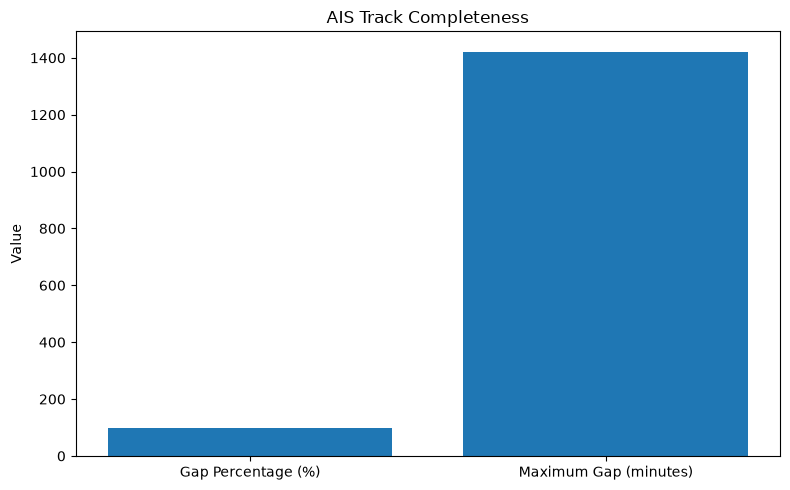

In [11]:
metrics = {
    "Gap Percentage (%)": gap_percentage,
    "Maximum Gap (minutes)": max_gap
}

plt.figure(figsize=(8, 5))

plt.bar(metrics.keys(), metrics.values())

plt.ylabel("Value")
plt.title("AIS Track Completeness")

plt.tight_layout()
plt.show()

In [12]:
vessel_completeness = (
    df.groupby("mmsi")
      .agg(
          total_intervals=("gap_minutes", "count"),
          gap_intervals=("gap_minutes", lambda x: (x > 1).sum()),
          max_gap_minutes=("gap_minutes", "max")
      )
)

vessel_completeness["gap_percentage"] = (
    vessel_completeness["gap_intervals"]
    / vessel_completeness["total_intervals"]
    * 100
)

vessel_completeness.head()

,total_intervals,gap_intervals,max_gap_minutes,gap_percentage
mmsi,,,,
103669999,37,37,419.950000,100.000000
112119600,8,8,42.483333,100.000000
123456789,328,328,32.966667,100.000000
155017179,359,359,74.966667,100.000000
200000000,894,873,45.233333,97.651007


In [13]:
print("Average gap percentage across vessels:",
      vessel_completeness["gap_percentage"].mean())

print("Maximum observed gap:",
      vessel_completeness["max_gap_minutes"].max(), "minutes")

Average gap percentage across vessels: 99.15718361562263
Maximum observed gap: 1422.0666666666666 minutes
